# Step 3: Train RF-DETR on Swimming Pools

Trains RF-DETR Nano and Small via transfer learning on the manually-cleaned Roboflow COCO export, then compares against YOLO26 from Step 2.

Runtime: A100 GPU, ~30-40 min for both variants.

## Setup

In [1]:
!nvidia-smi

Mon Jun  1 16:18:46 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-40GB          Off |   00000000:00:04.0 Off |                    0 |
| N/A   32C    P0             51W /  400W |       0MiB /  40960MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

In [2]:
%pip install -q 'rfdetr[train,loggers]>=1.4.0' supervision faster-coco-eval pandas matplotlib
import rfdetr
from importlib.metadata import version
print('rfdetr', version('rfdetr'))

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.1/60.1 kB 7.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.4/49.4 kB 6.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 6.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.5/43.5 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 319.8/319.8 kB 33.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 251.6/251.6 kB 31.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 588.1/588.1 kB 57.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 8.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 852.4/852.4 kB 69.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 67.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 99.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 94.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

## Load COCO dataset from Drive

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
import zipfile, pathlib

ZIP_PATH = '/content/drive/MyDrive/IE/CV/roboflow/Pools.coco.zip'
DATA_DIR = pathlib.Path('/content/dataset_coco')

DATA_DIR.mkdir(parents=True, exist_ok=True)
with zipfile.ZipFile(ZIP_PATH) as z:
    z.extractall(DATA_DIR)

for split in ['train', 'valid', 'test']:
    p = DATA_DIR / split / '_annotations.coco.json'
    print(f'{split}: {p.exists()}  {p}')

train: True  /content/dataset_coco/train/_annotations.coco.json
valid: True  /content/dataset_coco/valid/_annotations.coco.json
test: True  /content/dataset_coco/test/_annotations.coco.json


## Training configuration

| Parameter | Value |
|---|---|
| Backbone | DINOv2 ViT (pretrained, frozen for warm-up) |
| Optimizer | AdamW (RF-DETR default) |
| LR | 1e-4 head, 1e-5 backbone (RF-DETR defaults) |
| LR scheduler | Step decay (RF-DETR default) |
| Epochs | 100 |
| Batch size | 8, grad_accum=2 (effective 16, matches YOLO26) |
| Resolution | 672 (divisible by 14 and 56; closest valid value to the 640 of YOLO26) |
| Hardware | NVIDIA A100 40 GB |

## RF-DETR configuration rationale

RF-DETR is trained from the COCO-pretrained checkpoint (a DINOv2 ViT backbone with a transformer detection head), fine-tuned to the single pool class. The hyperparameters are mostly RF-DETR's published defaults, with two deliberate choices that keep the comparison against YOLO26 fair:

- **Effective batch 16.** Physical batch 8 with gradient accumulation 2 matches the batch-16 effective size used for the YOLO models.
- **Resolution 672.** RF-DETR's DINOv2 backbone needs input divisible by both 14 and 56, which 640 (the YOLO size) fails. 672 is the closest valid value; the 5% resolution gap is a fairness caveat, not a defect.

Optimizer (AdamW), the 1e-4 head / 1e-5 backbone learning rates, and the step-decay schedule are RF-DETR defaults. Training runs for 100 epochs with seed 0.

In [5]:
RESOLUTION = 672

TRAIN_CFG = dict(
    dataset_dir=str(DATA_DIR),
    epochs=100,
    batch_size=8,
    grad_accum_steps=2,
    seed=0,
)
for k, v in TRAIN_CFG.items(): print(f'{k:18s} = {v}')

dataset_dir        = /content/dataset_coco
epochs             = 100
batch_size         = 8
grad_accum_steps   = 2
seed               = 0


## Train Nano and Small

In [6]:
import time, gc, torch, pathlib
import torch.nn as nn
from rfdetr import RFDETRNano, RFDETRSmall

results = {}

def count_params(m):
    if isinstance(m, nn.Module):
        return sum(p.numel() for p in m.parameters())
    for attr in ('model', 'net', 'module'):
        sub = getattr(m, attr, None)
        if sub is not None:
            return count_params(sub)
    return 0

for name, cls in [('rfdetr_nano', RFDETRNano), ('rfdetr_small', RFDETRSmall)]:
    print(f'\n=== {name} ===')
    gc.collect(); torch.cuda.empty_cache()
    t0 = time.time()
    model = cls(resolution=RESOLUTION)
    out_dir = pathlib.Path(f'/content/runs/rfdetr/{name}')
    model.train(output_dir=str(out_dir), **TRAIN_CFG)
    best = out_dir / 'checkpoint_best_total.pth'
    if not best.exists():
        best = next(out_dir.glob('checkpoint_best*.pth'))
    results[name] = {
        'params': count_params(model),
        'train_time_s': time.time() - t0,
        'best_weights': str(best),
    }
    del model


=== rfdetr_nano ===
[2026-06-01 16:20:41] [INFO] rf-detr - Downloading pretrained weights for /root/.roboflow/models/rf-detr-nano.pth


/root/.roboflow/models/rf-detr-nano.pth:   0%|          | 0.00/349M [00:00<?, ?iB/s]

[2026-06-01 16:21:04] [INFO] rf-detr - MD5 validation successful for /root/.roboflow/models/rf-detr-nano.pth


[2026-06-01 16:21:04] [WARNING] rf-detr - Using a different number of positional encodings than DINOv2, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.
[2026-06-01 16:21:04] [WARNING] rf-detr - Using patch size 16 instead of 14, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.


[2026-06-01 16:21:05] [INFO] rf-detr - File /root/.roboflow/models/rf-detr-nano.pth already exists with correct MD5 hash.


...

INFO:lightning_fabric.utilities.seed:Seed set to 0


Output()

[2026-06-01 16:42:56] [INFO] rf-detr - Best EMA mAP improved to 0.0021 (epoch 0)
[2026-06-01 16:43:09] [INFO] rf-detr - Best regular mAP saved to /content/runs/rfdetr/rfdetr_small/checkpoint_best_regular.pth (epoch 0)
[2026-06-01 16:43:09] [INFO] rf-detr - Best EMA mAP improved to 0.5613 (epoch 0)
[2026-06-01 16:43:23] [INFO] rf-detr - Best regular mAP saved to /content/runs/rfdetr/rfdetr_small/checkpoint_best_regular.pth (epoch 1)
[2026-06-01 16:43:23] [INFO] rf-detr - Best EMA mAP improved to 0.6371 (epoch 1)
[2026-06-01 16:43:51] [INFO] rf-detr - Best regular mAP saved to /content/runs/rfdetr/rfdetr_small/checkpoint_best_regular.pth (epoch 3)
[2026-06-01 16:43:51] [INFO] rf-detr - Best EMA mAP improved to 0.6420 (epoch 3)
[2026-06-01 16:44:19] [INFO] rf-detr - Best regular mAP saved to /content/runs/rfdetr/rfdetr_small/checkpoint_best_regular.pth (epoch 5)
[2026-06-01 16:44:19] [INFO] rf-detr - Best EMA mAP improved to 0.6637 (epoch 5)
[2026-06-01 16:45:29] [INFO] rf-detr - Best reg

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=100` reached.


[2026-06-01 17:05:51] [INFO] rf-detr - Best total checkpoint saved from EMA (regular=0.6865, ema=0.6878)


## Validation and test metrics (mAP via supervision)

In [7]:
import supervision as sv
from supervision.metrics import MeanAveragePrecision
from PIL import Image
import numpy as np

def iou_matrix(a, b):
    a = np.asarray(a, float); b = np.asarray(b, float)
    if len(a) == 0 or len(b) == 0: return np.zeros((len(a), len(b)))
    x1 = np.maximum(a[:, None, 0], b[None, :, 0]); y1 = np.maximum(a[:, None, 1], b[None, :, 1])
    x2 = np.minimum(a[:, None, 2], b[None, :, 2]); y2 = np.minimum(a[:, None, 3], b[None, :, 3])
    inter = np.clip(x2 - x1, 0, None) * np.clip(y2 - y1, 0, None)
    aa = (a[:, 2] - a[:, 0]) * (a[:, 3] - a[:, 1])
    bb = (b[:, 2] - b[:, 0]) * (b[:, 3] - b[:, 1])
    union = aa[:, None] + bb[None, :] - inter
    return np.where(union > 0, inter / union, 0)

def pr_at(preds, targets, conf=0.25, thr=0.5):
    TP = FP = FN = 0
    for d, t in zip(preds, targets):
        keep = d.confidence > conf
        db, dc = d.xyxy[keep], d.confidence[keep]
        gb = t.xyxy
        if len(gb) == 0: FP += len(db); continue
        if len(db) == 0: FN += len(gb); continue
        m = iou_matrix(db, gb); matched = set()
        for di in np.argsort(-dc):
            best_j, best_iou = -1, thr
            for gj in range(len(gb)):
                if gj in matched: continue
                if m[di, gj] >= best_iou: best_iou, best_j = m[di, gj], gj
            if best_j >= 0: TP += 1; matched.add(best_j)
            else: FP += 1
        FN += len(gb) - len(matched)
    P = TP / (TP + FP) if (TP + FP) else 0
    R = TP / (TP + FN) if (TP + FN) else 0
    return P, R, TP, FP, FN

def evaluate(model, split_dir):
    ds = sv.DetectionDataset.from_coco(
        images_directory_path=str(split_dir),
        annotations_path=str(split_dir / '_annotations.coco.json'),
    )
    preds, targets = [], []
    for path, _, gt in ds:
        img = Image.open(path).convert('RGB')
        det = model.predict(img, threshold=0.01)
        preds.append(det); targets.append(gt)
    mp = MeanAveragePrecision().update(preds, targets).compute()
    P, R, TP, FP, FN = pr_at(preds, targets)
    return {
        'mAP50':    float(mp.map50),
        'mAP50_95': float(mp.map50_95),
        'precision': float(P),
        'recall':    float(R),
        'TP': TP, 'FP': FP, 'FN': FN,
    }

for name, cls in [('rfdetr_nano', RFDETRNano), ('rfdetr_small', RFDETRSmall)]:
    print(f'\n--- {name} ---')
    model = cls(resolution=RESOLUTION, pretrain_weights=results[name]['best_weights'])
    model.optimize_for_inference()
    results[name]['val']  = evaluate(model, DATA_DIR / 'valid')
    results[name]['test'] = evaluate(model, DATA_DIR / 'test')
    print('  val ', results[name]['val'])
    print('  test', results[name]['test'])
    del model
    gc.collect(); torch.cuda.empty_cache()

[2026-06-01 17:05:51] [WARNING] rf-detr - Using a different number of positional encodings than DINOv2, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.
[2026-06-01 17:05:51] [WARNING] rf-detr - Using patch size 16 instead of 14, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.



--- rfdetr_nano ---


[2026-06-01 17:05:52] [WARNING] rf-detr - Checkpoint has 2 classes but model is configured for 90. Using checkpoint class count (2). Pass num_classes=2 to suppress this warning.
[2026-06-01 17:05:52] [WARNING] rf-detr - load_pretrain_weights: args.num_queries absent; inferred ckpt_num_queries=300 from tensor rows 3900 ÷ ckpt_group_detr=13.
[transformers] `loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.


  val  {'mAP50': 0.8964075446128845, 'mAP50_95': 0.6637677550315857, 'precision': 0.92, 'recall': 0.8518518518518519, 'TP': 69, 'FP': 6, 'FN': 12}
  test {'mAP50': 0.99787837266922, 'mAP50_95': 0.8073315620422363, 'precision': 1.0, 'recall': 0.9487179487179487, 'TP': 37, 'FP': 0, 'FN': 2}


[2026-06-01 17:06:00] [WARNING] rf-detr - Using a different number of positional encodings than DINOv2, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.
[2026-06-01 17:06:00] [WARNING] rf-detr - Using patch size 16 instead of 14, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.



--- rfdetr_small ---


[2026-06-01 17:06:01] [WARNING] rf-detr - Checkpoint has 2 classes but model is configured for 90. Using checkpoint class count (2). Pass num_classes=2 to suppress this warning.
[2026-06-01 17:06:01] [WARNING] rf-detr - load_pretrain_weights: args.num_queries absent; inferred ckpt_num_queries=300 from tensor rows 3900 ÷ ckpt_group_detr=13.


  val  {'mAP50': 0.9161000847816467, 'mAP50_95': 0.6876970529556274, 'precision': 0.8974358974358975, 'recall': 0.8641975308641975, 'TP': 70, 'FP': 8, 'FN': 11}
  test {'mAP50': 0.9963932037353516, 'mAP50_95': 0.7854814529418945, 'precision': 0.9736842105263158, 'recall': 0.9487179487179487, 'TP': 37, 'FP': 1, 'FN': 2}


## Comparison table (RF-DETR vs YOLO26)

In [8]:
import pandas as pd

rows = []
for name, r in results.items():
    rows.append({
        'model': name,
        'mAP@50':    r['val']['mAP50'],
        'mAP@50-95': r['val']['mAP50_95'],
        'Precision': r['val']['precision'],
        'Recall':    r['val']['recall'],
        'Params (M)': r['params'] / 1e6,
        'Train time (s)': r['train_time_s'],
    })
df_rf = pd.DataFrame(rows).set_index('model').round(4)

YOLO_CSV = '/content/drive/MyDrive/IE/CV/results/yolo26_hbb/comparison.csv'
try:
    df_yolo = pd.read_csv(YOLO_CSV, index_col=0)
    df_combined = pd.concat([df_yolo, df_rf])
    print('Combined comparison (YOLO26 + RF-DETR):')
    print(df_combined.to_string())
    df_combined.to_csv('/content/rfdetr_combined_comparison.csv')
except FileNotFoundError:
    print(f'YOLO26 CSV not found at {YOLO_CSV} -- run Step 2 first to get the comparison')
    print(df_rf.to_string())
df_rf

Combined comparison (YOLO26 + RF-DETR):
                mAP@50  mAP@50-95  Precision    Recall  Params (M)  Train time (s)
yolo26n       0.912043   0.637144   0.895155  0.843284    2.375031      291.197755
yolo26s       0.891031   0.617326   0.862136  0.849268    9.465567      308.076620
yolo26m       0.902785   0.587363   0.876495  0.788556   20.350223      369.842500
yolo26l       0.909090   0.589780   0.944114  0.839506   24.746511      454.089560
rfdetr_nano   0.896400   0.663800   0.920000  0.851900   30.606900     1304.802500
rfdetr_small  0.916100   0.687700   0.897400  0.864200   32.078700     1405.134700


,mAP@50,mAP@50-95,Precision,Recall,Params (M),Train time (s)
model,,,,,,
rfdetr_nano,0.8964,0.6638,0.9200,0.8519,30.6069,1304.8025
rfdetr_small,0.9161,0.6877,0.8974,0.8642,32.0787,1405.1347


## Did RF-DETR outperform the YOLO-based detectors?

Only partially, and the answer depends on which axis you look along (the combined table above stacks RF-DETR against YOLO26).

**Headline mAP.** RF-DETR beats every YOLO26 HBB model on mAP@50-95 by 0.025 to 0.10 points, a meaningful margin that points to the DINOv2 backbone providing stronger spatial priors than COCO-trained CNN backbones for overhead imagery. RF-DETR does **not** beat YOLO11-OBB or YOLO26-OBB at any matched parameter budget (notebook 4), because this dataset's failure modes are dominated by rotation and RF-DETR's boxes are axis-aligned just like YOLO26 HBB. OBB sidesteps the rotation issue entirely; RF-DETR cannot.

**Robustness.** RF-DETR holds higher recall than every YOLO26 HBB variant on validation (0.852 and 0.864 vs 0.789 to 0.849) at competitive precision (0.920 and 0.897, mid-range against the 0.862 to 0.944 YOLO26 HBB band), so it is not trading one off against the other. On the test set RF-DETR Nano produced zero false positives (precision 1.000) while the best YOLO26 HBB variant produced two. The Hungarian set-prediction matcher also removes the need for a tuned confidence threshold to balance precision and recall, a robustness property NMS-based YOLO heads do not share.

**Small-object detection.** Not improved. RF-DETR Small misses the same tiny pools (108_PNG, 221_png) that YOLO26 HBB and YOLO11s-OBB miss; small-object recall on this dataset is limited by input resolution (imgsz 640 / 672), not by architecture.

**Generalization.** Strongest of the three families on this dataset. The val-to-test mAP@50-95 gap is +0.143 for RF-DETR Nano (0.664 to 0.807), compared with +0.055 for YOLO26n HBB (0.637 to 0.692) and +0.050 for YOLO11s-OBB (0.737 to 0.787). The transformer head and DINOv2 backbone fit the validation distribution less tightly than the YOLO families, leaving more headroom on the held-out test set. With only 29 test images this gap is itself noisy, but the direction is consistent across both metrics and both RF-DETR scales.

## Failure analysis (best variant, test set)

[2026-06-01 17:06:09] [WARNING] rf-detr - Using a different number of positional encodings than DINOv2, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.
[2026-06-01 17:06:09] [WARNING] rf-detr - Using patch size 16 instead of 14, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.


Best RF-DETR variant: rfdetr_small


[2026-06-01 17:06:10] [WARNING] rf-detr - Checkpoint has 2 classes but model is configured for 90. Using checkpoint class count (2). Pass num_classes=2 to suppress this warning.
[2026-06-01 17:06:10] [WARNING] rf-detr - load_pretrain_weights: args.num_queries absent; inferred ckpt_num_queries=300 from tensor rows 3900 ÷ ckpt_group_detr=13.


False positives: 1   False negatives: 2


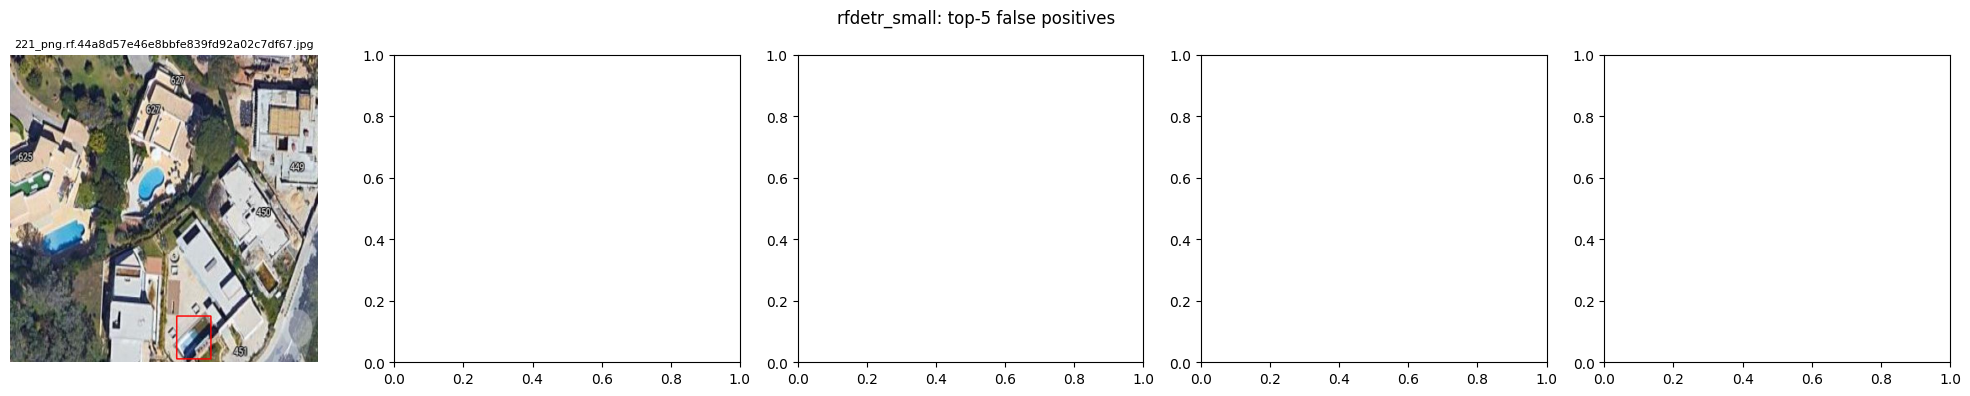

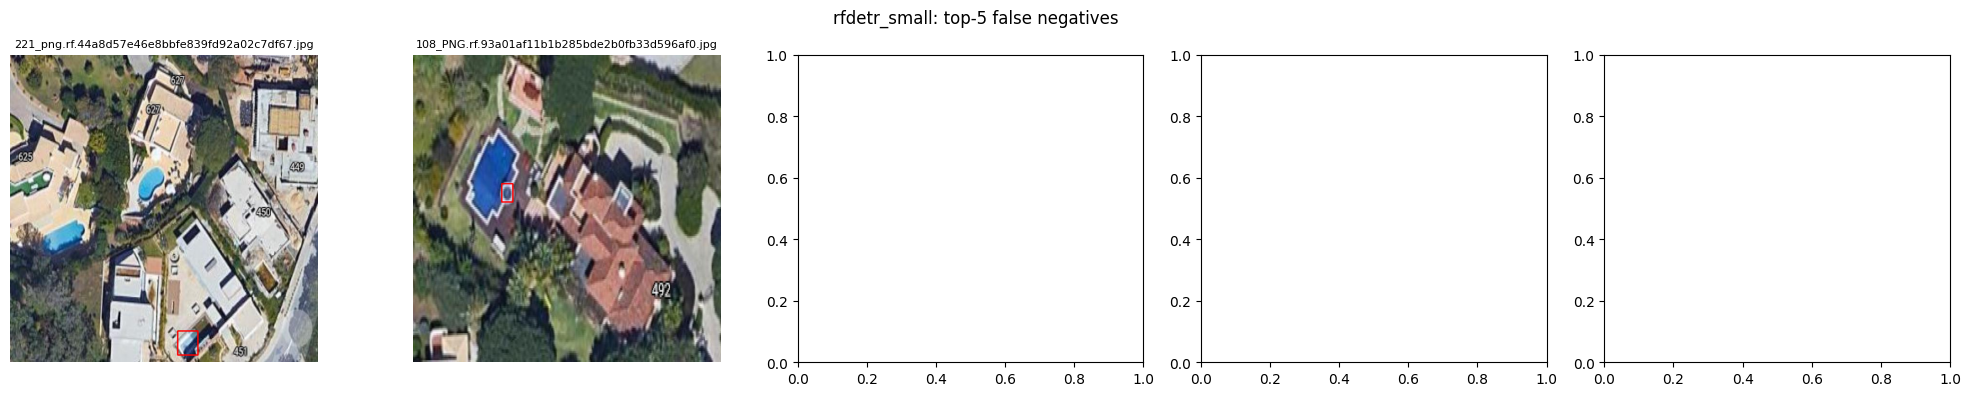

In [9]:
import cv2, matplotlib.pyplot as plt, pathlib

BEST = max(results, key=lambda n: results[n]['val']['mAP50_95'])
print(f'Best RF-DETR variant: {BEST}')

cls = {'rfdetr_nano': RFDETRNano, 'rfdetr_small': RFDETRSmall}[BEST]
model = cls(resolution=RESOLUTION, pretrain_weights=results[BEST]['best_weights'])
model.optimize_for_inference()

test_dir = DATA_DIR / 'test'
test_ds = sv.DetectionDataset.from_coco(
    images_directory_path=str(test_dir),
    annotations_path=str(test_dir / '_annotations.coco.json'),
)

CONF, IOU_TH = 0.25, 0.5
fps, fns = [], []  # (img_path, box, score_or_area)

for path, _, gt in test_ds:
    img = Image.open(path).convert('RGB')
    det = model.predict(img, threshold=CONF)
    db, dc = det.xyxy, det.confidence
    gb = gt.xyxy
    matched_gt, matched_pr = set(), set()
    if len(db) and len(gb):
        m = iou_matrix(db, gb)
        for di in np.argsort(-dc):
            best_j, best_iou = -1, IOU_TH
            for gj in range(len(gb)):
                if gj in matched_gt: continue
                if m[di, gj] >= best_iou: best_iou, best_j = m[di, gj], gj
            if best_j >= 0: matched_gt.add(best_j); matched_pr.add(int(di))
    for i in range(len(db)):
        if i not in matched_pr: fps.append((path, db[i].tolist(), float(dc[i])))
    for j in range(len(gb)):
        if j not in matched_gt:
            area = (gb[j, 2] - gb[j, 0]) * (gb[j, 3] - gb[j, 1])
            fns.append((path, gb[j].tolist(), float(area)))

fps.sort(key=lambda x: -x[2])
fns.sort(key=lambda x: -x[2])
print(f'False positives: {len(fps)}   False negatives: {len(fns)}')

def show(items, title, n=5):
    fig, axes = plt.subplots(1, n, figsize=(4*n, 4))
    for ax, (p, box, _) in zip(axes, items[:n]):
        img = cv2.cvtColor(cv2.imread(str(p)), cv2.COLOR_BGR2RGB)
        x1, y1, x2, y2 = map(int, box)
        cv2.rectangle(img, (x1, y1), (x2, y2), (255, 0, 0), 2)
        ax.imshow(img); ax.set_title(pathlib.Path(p).name, fontsize=8); ax.axis('off')
    fig.suptitle(title); plt.tight_layout(); plt.show()

show(fps, f'{BEST}: top-5 false positives')
show(fns, f'{BEST}: top-5 false negatives')

### Failure modes (RF-DETR Small)

On the test set the validation-best RF-DETR (Small) produces **1 false positive and 2 false negatives** at conf >= 0.25 / IoU >= 0.5 (galleries above). Both false negatives are the sub-50-pixel pools 108_PNG and 221_png that every architecture in this project misses: they mark the residual small-object detection limit at this input resolution rather than an RF-DETR-specific weakness. Notebook 4 compares these misses across all three best models.

## Save results to Drive

In [10]:
import shutil

OUT = pathlib.Path('/content/drive/MyDrive/IE/CV/results/rfdetr')
OUT.mkdir(parents=True, exist_ok=True)

df_rf.to_csv(OUT / 'comparison.csv')
for name, r in results.items():
    src = pathlib.Path(r['best_weights'])
    if src.exists():
        shutil.copy(src, OUT / f'{name}_best.pth')
print(f'Saved to {OUT}')

Saved to /content/drive/MyDrive/IE/CV/results/rfdetr
